# **Import libraries**

In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, train_test_split, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from itertools import product

from xgboost import XGBRegressor
import shap

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Import dataset**

In [9]:
# Import the merged csv file of image analysis parameters + bioreactor process parameters

csv_file_path = (".../Merged_df.csv")

df_ML = pd.read_csv(csv_file_path)

# one-hot incoding
# 1. Inoculum: 'Preculture' or 'Conidia' → One-hot
df_ML['Inoculum'] = df_ML['Inoculum'].map({'Conidia': 0, 'Pre-culture': 1})

# 2. Stirring rate: extract numeric from 'e.g. "200 rpm"', fill missing with 0 (for shake flasks)
df_ML['Stirring rate'] = df_ML['Stirring rate'].str.extract(r'(\d+)').astype(float)
df_ML['Stirring rate'] = df_ML['Stirring rate'].fillna(0)

# 3. Overpressure: 'yes' = 1, 'no' = 0, '-' (flasks) = 0
df_ML['Overpressure'] = df_ML['Overpressure'].astype(str).str.lower().map({'yes': 1, 'no': 0, '-': 0})
df_ML['Overpressure'] = df_ML['Overpressure'].fillna(0)

# 4. Medium: e.g., 'standard', others → One-hot encode
df_ML['Medium_Nitrogen'] = df_ML['Medium'].str.contains("Nitrogen", case=False).astype(int)
df_ML['Medium_Phosphate'] = df_ML['Medium'].str.contains("Phosphate", case=False).astype(int)

df_ML

,Experiment,Bioreactor,Imaging time [h],Wellplate,Count per image,Total area [$\mu m^2$],Total perimeter [$\mu m$],Degree centrality,Inoculum,Stirring rate,...,CDW [g/l],PY/CDW [mg/g],qP = PY/CDW [mg/g/h],STY [mg/l/h],Glucose [g/l],Induction time [h],Integral OTR [mmol/l],ESF₁₀ disk diameter [µm],Medium_Nitrogen,Medium_Phosphate
0,AP00425,F3 0125 AN,144.0,XY05,336,1515049.76,321743.78,0.70,1,550.0,...,20.5,4.30,0.03,0.61,4.7,10.0,1385.92,90.5856,0,0
1,AP00425,F3 0125 AN,72.0,XY07,190,5206077.26,301554.09,0.92,1,550.0,...,17.4,0.90,0.01,0.21,46.5,10.0,574.98,603.9040,0,0
2,AP00425,F3 0125 AN,72.0,XY08,288,1563672.35,280141.64,0.74,1,550.0,...,17.4,0.90,0.01,0.21,46.5,10.0,574.98,75.4880,0,0
3,AP00425,F3 0125 AN,72.0,XY09,233,3167305.53,259614.71,0.88,1,550.0,...,17.4,0.90,0.01,0.21,46.5,10.0,574.98,362.3424,0,0
4,AP00425,F3 0125 AN,72.0,XY10,229,4083669.38,267359.58,0.91,1,550.0,...,17.4,0.90,0.01,0.21,46.5,10.0,574.98,407.6352,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
533,AP01224,K8 0224 AN,108.0,XY11,1050,978919.28,446086.14,0.35,0,1140.0,...,12.8,22.37,-0.95,2.65,0.0,19.0,NaN,7.5488,1,1
534,AP01224,K8 0224 AN,84.0,XY20,806,4166397.56,1741954.19,0.40,0,1140.0,...,10.8,49.11,-0.53,6.31,0.0,19.0,NaN,7.5488,1,1
535,AP01224,K8 0224 AN,84.0,XY19,807,3954341.59,1699443.33,0.38,0,1140.0,...,10.8,49.11,-0.53,6.31,0.0,19.0,NaN,7.5488,1,1
536,AP01224,K8 0224 AN,108.0,XY19,1301,1386405.80,633591.91,0.34,0,1140.0,...,12.8,22.37,-0.95,2.65,0.0,19.0,NaN,7.5488,1,1


# **XGBoost - stratified test set**

In [10]:
# ==========================================================
# === DATA PREPARATION =====================================
# ==========================================================

df_ML.rename(columns={
    'Post-induction time [h]': 'Post-induction time',
    'Viscosity [Pa s]': 'Viscosity',
    'Glucose [g/l]': 'Glucose',
    'Integral OTR [mmol/l]': 'Integral OTR',
    'CDW [g/l]': 'CDW',
    'Count per image': 'Detected fungal structures',
    r'ESF₁₀ disk diameter [µm]': 'ESF₁₀ disk diameter',
    r'Total area [$\mu m^2$]': 'Total area',
    r'Total perimeter [$\mu m$]': 'Total perimeter'}, inplace=True)

target_column = ['Psilocybin [mg/l] Mean']

feature_columns = [
    'Post-induction time', 'Inoculum', 'Stirring rate',
    'Overpressure', 'Medium_Nitrogen', 'Medium_Phosphate',
    'Detected fungal structures', 'Total area', 'Total perimeter',
    'Degree centrality', 'ESF₁₀ disk diameter'
]

X = df_ML[feature_columns].reset_index(drop=True)
y = df_ML[target_column].reset_index(drop=True)

# ==========================================================
# === SAMPLE WEIGHTS =======================================
# ==========================================================

df_ML = df_ML.reset_index(drop=True)

df_ML['condition'] = (
    df_ML['Bioreactor'].astype(str) + '_' +
    df_ML['Post-induction time'].astype(str)
)

condition_counts = df_ML['condition'].value_counts()
sample_weights = df_ML['condition'].map(lambda c: 1 / condition_counts[c]).reset_index(drop=True)

# ==========================================================
# === STRATIFICATION LABELS ================================
# ==========================================================

n_bins = 5

post_time_bin = pd.qcut(
    df_ML['Post-induction time'],
    q=n_bins,
    labels=False,
    duplicates='drop'
).astype(int)

stir_level = df_ML['Stirring rate'].round(0).astype(int)

df_bin = df_ML[
    ['Inoculum', 'Overpressure', 'Medium_Nitrogen', 'Medium_Phosphate']
].astype(int)

df_strat = pd.DataFrame({
    'PostTimeBin': post_time_bin,
    'StirRateLvl': stir_level
}).join(df_bin)

strata = df_strat.astype(str).agg('_'.join, axis=1)

# ==========================================================
# === OUTER SPLIT: TRAIN+VAL / TEST (80 / 20) ===============
# ==========================================================

X_trainval, X_test, \
y_trainval, y_test, \
sw_trainval, sw_test, \
strata_trainval, strata_test = train_test_split(
    X, y, sample_weights, strata,
    test_size=0.20,
    random_state=42,
    stratify=strata
)

# ==========================================================
# === INNER SPLIT: TRAIN / VAL (70 / 10 TOTAL) ==============
# ==========================================================

X_train, X_val, \
y_train, y_val, \
sw_train, sw_val = train_test_split(
    X_trainval, y_trainval, sw_trainval,
    test_size=0.125,          # 12.5% of 80% = 10%
    random_state=42,
    stratify=strata_trainval
)

# ==========================================================
# === FEATURE SCALING ======================================
# ==========================================================

scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_columns,
    index=X_train.index
)

X_val = pd.DataFrame(
    scaler.transform(X_val),
    columns=feature_columns,
    index=X_val.index
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_columns,
    index=X_test.index
)

# ==========================================================
# === MODEL DEFINITION =====================================
# ==========================================================

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    learning_rate=0.3,
    max_depth=6,
    n_estimators=100,
    random_state=42
 )

# ==========================================================
# === TRAINING + VALIDATION ================================
# ==========================================================

xgb_model.fit(X_train, y_train, sample_weight=sw_train)

y_val_pred = np.maximum(xgb_model.predict(X_val), 0)

val_r2 = r2_score(y_val, y_val_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)

print("Validation R²:", val_r2)
print("Validation MAE:", val_mae)

# ==========================================================
# === FINAL TRAINING ON TRAIN + VAL ========================
# ==========================================================

#X_final = pd.concat([X_train, X_val])
#y_final = pd.concat([y_train, y_val])
#sw_final = pd.concat([sw_train, sw_val])
#xgb_model.fit(X_final, y_final, sample_weight=sw_final)

xgb_model.fit(X_train, y_train, sample_weight=sw_train)

# ==========================================================
# === TEST EVALUATION (UNTOUCHED) ==========================
# ==========================================================

y_test_pred = np.maximum(xgb_model.predict(X_test), 0)

test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("Test R²:", test_r2)
print("Test MAE:", test_mae)

# ==========================================================
# === SAVE TEST PREDICTIONS ================================
# ==========================================================

test_predictions = pd.DataFrame({
    "Bioreactor": df_ML.loc[X_test.index, "Bioreactor"],
    "Post-induction time": df_ML.loc[X_test.index, "Post-induction time"],
    "Psilocybin [mg/l] Mean": y_test.values.flatten(),
    "Predicted": y_test_pred,
    "Set": "Test"
})

all_predictions_df = test_predictions.copy()

# ==========================================================
# === SPLIT SUMMARY (SANITY CHECK) =========================
# ==========================================================

N = len(df_ML)
print(f"Train: {len(X_train)} ({len(X_train)/N*100:.1f}%)")
print(f"Val:   {len(X_val)} ({len(X_val)/N*100:.1f}%)")
print(f"Test:  {len(X_test)} ({len(X_test)/N*100:.1f}%)")


Validation R²: 0.9779836535453796
Validation MAE: 13.018572807312012
Test R²: 0.9784806370735168
Test MAE: 11.252875328063965
Train: 376 (69.9%)
Val:   54 (10.0%)
Test:  108 (20.1%)


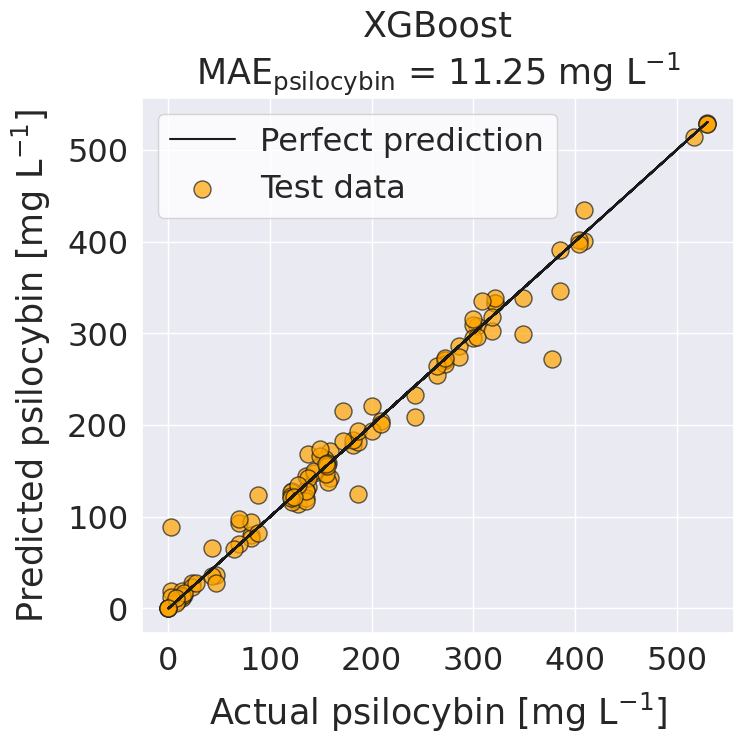

In [11]:
# Test set: Actual Psilocybin vs.Predicted Psilocybin
sns.set(style="darkgrid", font_scale = 2.1)
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(y_test, y_test, color='k', label='Perfect prediction')
ax.scatter(y_test, y_test_pred, edgecolor='k', facecolor='orange', s=150, alpha=0.7, label='Test data')
ax.set_xlabel(r"Actual psilocybin [mg L$^{-1}$]", labelpad=10)
ax.set_ylabel(r"Predicted psilocybin [mg L$^{-1}$]", labelpad=10)
ax.legend(facecolor='white', loc='upper left')
#ax.set_title(f'XGBoost\nTest $R^2$ = {test_r2:.2f},  MAE = {test_mae:.2f}')
ax.set_title(
    rf"XGBoost" "\n"
    rf"MAE$_{{\mathrm{{psilocybin}}}}$ = {test_mae:.2f} $\mathrm{{mg\ L^{{-1}}}}$"
)

fig.tight_layout()

In [ ]:
# Feature Importance Plots

sns.set(style="darkgrid", font_scale = 3.5)

# Initialize the SHAP explainer
explainer = shap.Explainer(xgb_model.predict, X_train)

# Compute SHAP values
shap_values = explainer(X_train)

PermutationExplainer explainer: 377it [01:11,  4.61it/s]


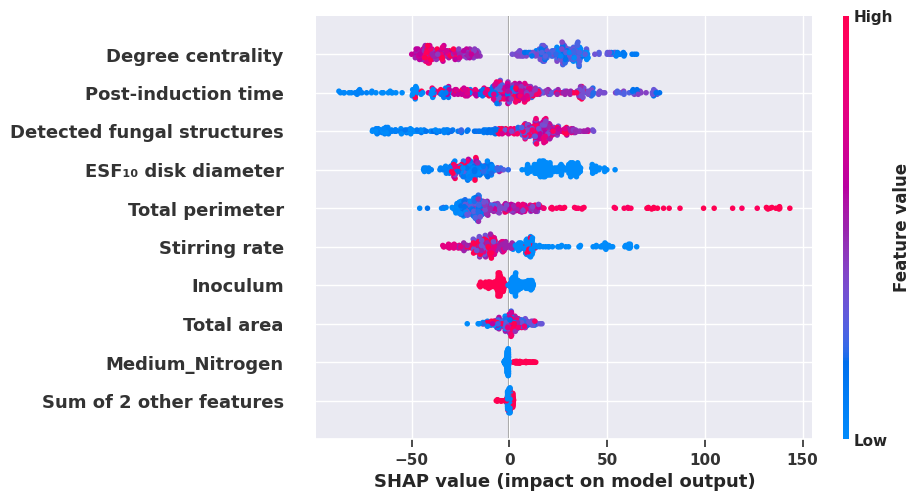

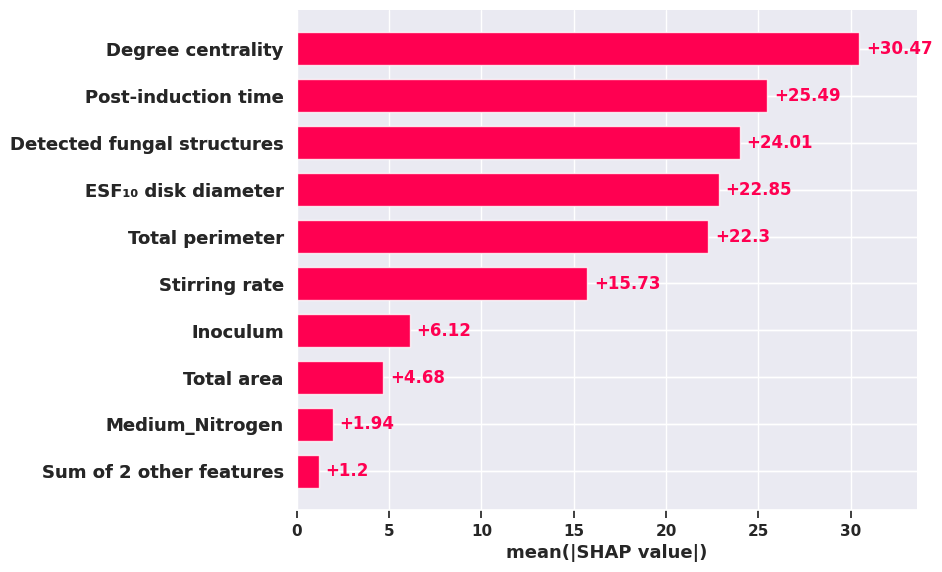

In [ ]:
shap.plots.beeswarm(shap_values)
shap.plots.bar(shap_values)

## **XGBoost parameter grid search**

In [13]:
# ==========================================================
# === PREPARE DATA =========================================
# ==========================================================

df_ML.rename(columns={
    'Post-induction time [h]': 'Post-induction time',
    'Viscosity [Pa s]': 'Viscosity',
    'Glucose [g/l]': 'Glucose',
    'Integral OTR [mmol/l]': 'Integral OTR',
    'CDW [g/l]': 'CDW',
    'Count per image': 'Detected fungal structures',
    r'ESF₁₀ disk diameter [µm]': 'ESF₁₀ disk diameter',
    r'Total area [$\mu m^2$]': 'Total area',
    r'Total perimeter [$\mu m$]': 'Total perimeter'}, inplace=True)

target_column = ['Psilocybin [mg/l] Mean']

feature_columns = [
    'Post-induction time', 'Inoculum', 'Stirring rate',
    'Overpressure', 'Medium_Nitrogen', 'Medium_Phosphate',
    'Detected fungal structures', 'Total area', 'Total perimeter',
    'Degree centrality', 'ESF₁₀ disk diameter'
]

target_column = ['Psilocybin [mg/l] Mean']

X = df_ML[feature_columns].copy()
y = df_ML[target_column].copy()

# ==========================================================
# === SAMPLE WEIGHTS =======================================
# ==========================================================

df_ML['condition'] = (
    df_ML['Bioreactor'].astype(str) + '_' +
    df_ML['Post-induction time'].astype(str)
)
condition_counts = df_ML['condition'].value_counts()
df_ML['sample_weight'] = df_ML['condition'].map(lambda c: 1 / condition_counts[c])
sample_weights = df_ML['sample_weight']

# ==========================================================
# === STRATIFICATION LABELS ================================
# ==========================================================

n_bins = 5
post_time_bin = pd.qcut(
    df_ML['Post-induction time'],
    q=n_bins,
    labels=False,
    duplicates='drop'
).astype(int)

stir_level = df_ML['Stirring rate'].round(0).astype(int)

df_bin = df_ML[
    ['Inoculum', 'Overpressure', 'Medium_Nitrogen', 'Medium_Phosphate']
].astype(int)

df_strat = pd.DataFrame({
    'PostTimeBin': post_time_bin,
    'StirRateLvl': stir_level,
}).join(df_bin)

strata = df_strat.astype(str).agg('_'.join, axis=1)

# ==========================================================
# === RESET INDICES ========================================
# ==========================================================

df_ML = df_ML.reset_index(drop=True)
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)
sample_weights = sample_weights.reset_index(drop=True)
strata = strata.reset_index(drop=True)

# ==========================================================
# === OUTER STRATIFIED TRAIN–TEST SPLIT (80 / 20) ==========
# ==========================================================

X_train_raw, X_test_raw, y_train_raw, y_test_raw, sw_train_raw, sw_test_raw = train_test_split(
    X, y, sample_weights,
    test_size=0.20,
    random_state=42,
    stratify=strata
)

# ==========================================================
# === SCALE FEATURES =======================================
# ==========================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

X_train = pd.DataFrame(X_train_scaled, columns=feature_columns)
X_test = pd.DataFrame(X_test_scaled, columns=feature_columns)

y_train = y_train_raw.reset_index(drop=True)
y_test = y_test_raw.reset_index(drop=True)
sw_train = sw_train_raw.reset_index(drop=True)
sw_test = sw_test_raw.reset_index(drop=True)

# ==========================================================
# === INNER STRATA (FOR NESTED SPLIT) ======================
# ==========================================================

strata_train = strata.loc[X_train_raw.index].reset_index(drop=True)

# ==========================================================
# === GRID SEARCH SPACE ====================================
# ==========================================================

learning_rates = [0.1, 0.15, 0.2, 0.25, 0.3]
max_depths = [3, 6, 9, 12]
n_estimators_list = [50, 100, 200, 300]

results = []

# ==========================================================
# === NESTED GRID SEARCH (70 / 10 inside training) =========
# ==========================================================

for lr, depth, n_est in product(learning_rates, max_depths, n_estimators_list):

    X_tr, X_val, y_tr, y_val, sw_tr, sw_val = train_test_split(
        X_train, y_train, sw_train,
        test_size=0.125,   # 12.5% → overall 10%
        random_state=42,
        stratify=strata_train
    )

    model = XGBRegressor(
        objective='reg:squarederror',
        learning_rate=lr,
        max_depth=depth,
        n_estimators=n_est,
        random_state=42
    )

    model.fit(X_tr, y_tr.values.ravel(), sample_weight=sw_tr)

    y_val_pred = np.maximum(model.predict(X_val), 0)

    results.append({
        "learning_rate": lr,
        "max_depth": depth,
        "n_estimators": n_est,
        "R2": r2_score(y_val, y_val_pred),
        "MAE": mean_absolute_error(y_val, y_val_pred)
    })

# ==========================================================
# === RESULTS SUMMARY ======================================
# ==========================================================

results_df = pd.DataFrame(results)

print("\n=== Best R² ===")
print(results_df.loc[results_df["R2"].idxmax()].round(4))

print("\n=== Best MAE ===")
print(results_df.loc[results_df["MAE"].idxmin()].round(4))




=== Best R² ===
learning_rate      0.2500
max_depth          3.0000
n_estimators     300.0000
R2                 0.9857
MAE               11.8603
Name: 51, dtype: float64

=== Best MAE ===
learning_rate      0.1500
max_depth          3.0000
n_estimators     300.0000
R2                 0.9839
MAE               11.5664
Name: 19, dtype: float64


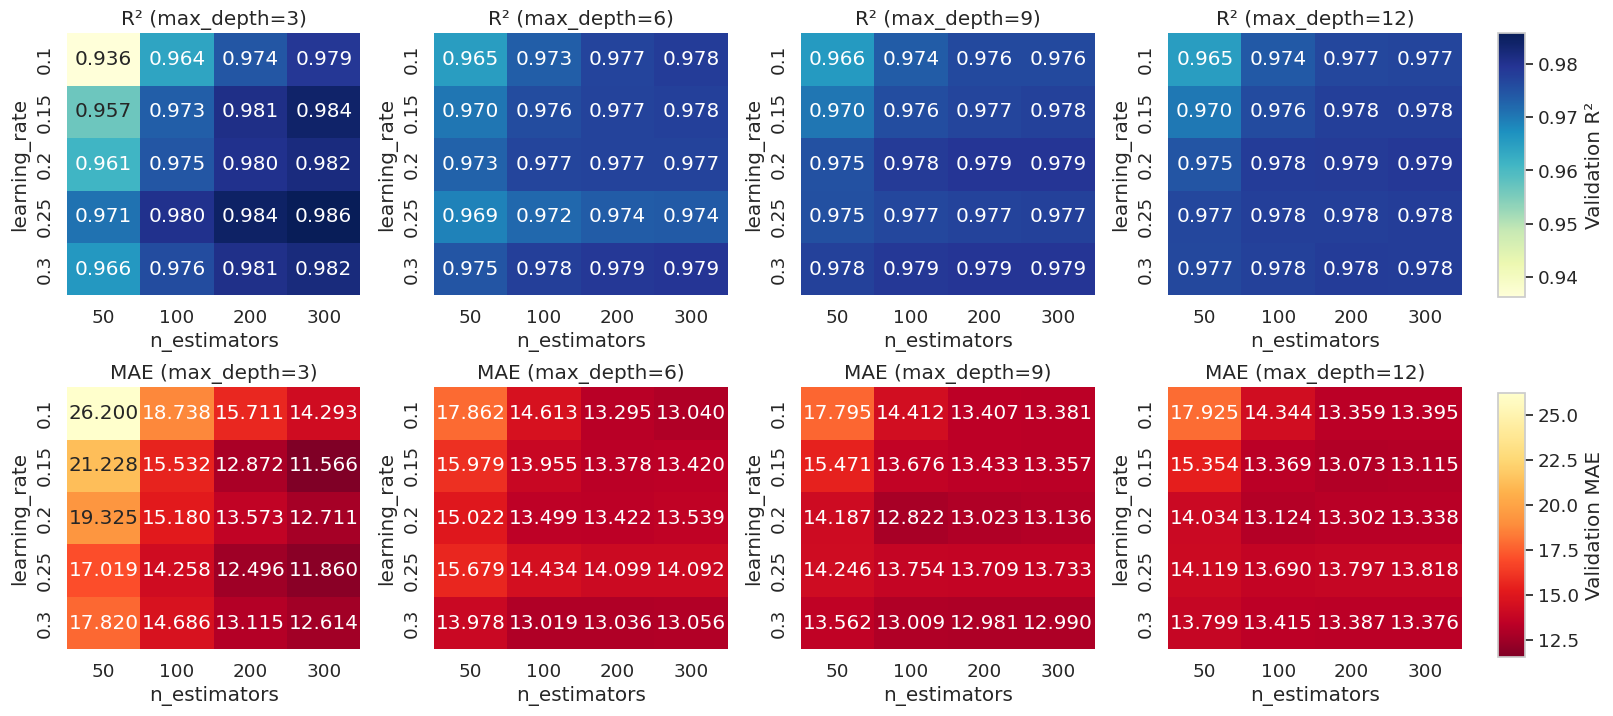

In [14]:
# ==========================================================
# === HEATMAP VISUALIZATION (SHARED COLOR SCALES + EXTERNAL CBARS)
# ==========================================================

sns.set(style="whitegrid", font_scale=1.2)

r2_min, r2_max = results_df["R2"].min(), results_df["R2"].max()
mae_min, mae_max = results_df["MAE"].min(), results_df["MAE"].max()

fig, axes = plt.subplots(
    2,
    len(max_depths),
    figsize=(4.5 * len(max_depths), 8),
    constrained_layout=False
)

# --- Plot heatmaps (NO colorbars here) ---
for i, depth in enumerate(max_depths):

    df_d = results_df[results_df["max_depth"] == depth]

    r2_data = df_d.pivot(
        index="learning_rate",
        columns="n_estimators",
        values="R2"
    )

    mae_data = df_d.pivot(
        index="learning_rate",
        columns="n_estimators",
        values="MAE"
    )

    sns.heatmap(
        r2_data,
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        vmin=r2_min,
        vmax=r2_max,
        ax=axes[0, i],
        cbar=False
    )
    axes[0, i].set_title(f"R² (max_depth={depth})")

    sns.heatmap(
        mae_data,
        annot=True,
        fmt=".3f",
        cmap="YlOrRd_r",
        vmin=mae_min,
        vmax=mae_max,
        ax=axes[1, i],
        cbar=False
    )
    axes[1, i].set_title(f"MAE (max_depth={depth})")

# --- Axis labels ---
for ax in axes.flatten():
    ax.set_xlabel("n_estimators")
    ax.set_ylabel("learning_rate")

# ==========================================================
# === ADD EXTERNAL COLORBARS ===============================
# ==========================================================

# Create ScalarMappables
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

sm_r2 = ScalarMappable(norm=Normalize(vmin=r2_min, vmax=r2_max), cmap="YlGnBu")
sm_mae = ScalarMappable(norm=Normalize(vmin=mae_min, vmax=mae_max), cmap="YlOrRd_r")
sm_r2.set_array([])
sm_mae.set_array([])

# Add colorbar axes (manual positioning)
cbar_ax_r2 = fig.add_axes([0.92, 0.55, 0.015, 0.33])   # [left, bottom, width, height]
cbar_ax_mae = fig.add_axes([0.92, 0.10, 0.015, 0.33])

cb_r2 = fig.colorbar(sm_r2, cax=cbar_ax_r2)
cb_mae = fig.colorbar(sm_mae, cax=cbar_ax_mae)

cb_r2.set_label("Validation R²")
cb_mae.set_label("Validation MAE")

# Adjust spacing so nothing overlaps
plt.subplots_adjust(right=0.90, hspace=0.35, wspace=0.25)

plt.show()


# **XGBoost - leave-one-out-cross-validation (LOOCV)**

In [ ]:
# LOOCV validation

df_ML.rename(columns={
    'Post-induction time [h]': 'Post-induction time',
    'Viscosity [Pa s]': 'Viscosity',
    'Glucose [g/l]': 'Glucose',
    'Integral OTR [mmol/l]': 'Integral OTR',
    'CDW [g/l]': 'CDW',
    'Count per image': 'Detected fungal structures',
    r'ESF₁₀ disk diameter [µm]': 'ESF₁₀ disk diameter',
    r'Total area [$\mu m^2$]': 'Total area',
    r'Total perimeter [$\mu m$]': 'Total perimeter'}, inplace=True)

target_column = ['Psilocybin [mg/l] Mean']

feature_columns = [
    'Post-induction time', 'Inoculum', 'Stirring rate',
    'Overpressure', 'Medium_Nitrogen', 'Medium_Phosphate',
    'Detected fungal structures', 'Total area', 'Total perimeter',
    'Degree centrality', 'ESF₁₀ disk diameter'
]

# Track performance for each bioreactor
bioreactor_r2_scores = {}
all_predictions = []   # 🔑 store predictions here

# Get all unique bioreactors
unique_bioreactors = df_ML['Bioreactor'].unique()
print(f"Number of Bioreactors: {len(unique_bioreactors)}")

# Loop over bioreactors
for test_bioreactor in unique_bioreactors:
    print(f"\nEvaluating Bioreactor: {test_bioreactor}")

    # Split into train/test
    test_df = df_ML[df_ML['Bioreactor'] == test_bioreactor].copy()
    train_df = df_ML[df_ML['Bioreactor'] != test_bioreactor].copy()

    # Prepare features and target
    X_train_raw = train_df[feature_columns]
    y_train = train_df[target_column]
    X_test_raw = test_df[feature_columns]
    y_test = test_df[target_column]

    # Compute sample weights
    train_df['condition'] = train_df['Bioreactor'].astype(str) + '_' + train_df['Post-induction time'].astype(str)
    condition_counts = train_df['condition'].value_counts()
    train_df['sample_weight'] = train_df['condition'].map(lambda cond: 1 / condition_counts[cond])
    sample_weights_train = train_df['sample_weight']

    # Standard scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)

    # Convert back to DataFrame
    X_train = pd.DataFrame(X_train_scaled, columns=feature_columns, index=X_train_raw.index)
    X_test = pd.DataFrame(X_test_scaled, columns=feature_columns, index=X_test_raw.index)

    # Initialize model
    xgb_model = XGBRegressor(
        objective='reg:squarederror',
        learning_rate=0.3,
        max_depth=6,
        n_estimators=100,
        random_state=42
    )

    # Cross-validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_r2 = []
    for train_idx, val_idx in kf.split(X_train):
        X_fold_train = X_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]
        w_fold_train = sample_weights_train.iloc[train_idx]

        xgb_model.fit(X_fold_train, y_fold_train, sample_weight=w_fold_train)
        y_val_pred = np.maximum(xgb_model.predict(X_fold_val), 0)
        cv_r2.append(r2_score(y_fold_val, y_val_pred))

    mean_cv_r2 = np.mean(cv_r2)
    print("Mean CV R² on training set:", mean_cv_r2)

    # Final training & test eval
    xgb_model.fit(X_train, y_train, sample_weight=sample_weights_train)
    # ✅ Clamp predictions to non-negative
    y_test_pred = np.maximum(xgb_model.predict(X_test), 0)

    # Metrics
    test_r2 = r2_score(y_test, y_test_pred) if len(y_test) > 0 else float("nan")
    test_mae = mean_absolute_error(y_test, y_test_pred) if len(y_test) > 0 else float("nan")

    print(f"  Test R² on {test_bioreactor}: {test_r2:.2f}, MAE={test_mae:.2f}")

    bioreactor_r2_scores[test_bioreactor] = {"R2": test_r2, "MAE": test_mae, "CV_R2": mean_cv_r2}

    # 🔑 Save predictions into list
    preds_df = pd.DataFrame({
        "Bioreactor": test_df["Bioreactor"],
        "Post-induction time": test_df["Post-induction time"],
        "Psilocybin [mg/l] Mean": y_test.values.ravel(),
        "Predicted": y_test_pred
    })
    all_predictions.append(preds_df)

# ==========================================================
# === FINAL SUMMARY ACROSS BIOREACTORS =====================
# ==========================================================
results_df = pd.DataFrame.from_dict(bioreactor_r2_scores, orient="index")

mean_r2  = results_df["R2"].mean()
mean_mae = results_df["MAE"].mean()
mean_cv  = results_df["CV_R2"].mean()

print("\n================= LOBO SUMMARY =================")
print(f"Mean Test R²  across bioreactors : {mean_r2:.3f}")
print(f"Mean Test MAE across bioreactors : {mean_mae:.2f} mg/L")
print(f"Mean CV R²   across bioreactors : {mean_cv:.3f}")
print("================================================")

# === Combine all predictions into one DataFrame ===
all_predictions_ML = pd.concat(all_predictions, ignore_index=True)
print("\n=== Combined Predictions DataFrame ===")
all_predictions_ML

Number of Bioreactors: 8

Evaluating Bioreactor: F3 0125 AN
Mean CV R² on training set: 0.9709979653358459
  Test R² on F3 0125 AN: -1.69, MAE=73.55

Evaluating Bioreactor: F8 0125 AN
Mean CV R² on training set: 0.9643890380859375
  Test R² on F8 0125 AN: -0.12, MAE=41.12

Evaluating Bioreactor: F8 0424 AN
Mean CV R² on training set: 0.9701982736587524
  Test R² on F8 0424 AN: 0.07, MAE=94.84

Evaluating Bioreactor: F9 0324 AN
Mean CV R² on training set: 0.9832682013511658
  Test R² on F9 0324 AN: 0.14, MAE=103.46

Evaluating Bioreactor: K7 0124 AN
Mean CV R² on training set: 0.9628817558288574
  Test R² on K7 0124 AN: -0.72, MAE=50.69

Evaluating Bioreactor: K7 0224 AN
Mean CV R² on training set: 0.9666202664375305
  Test R² on K7 0224 AN: -2.94, MAE=65.67

Evaluating Bioreactor: K8 0124 AN
Mean CV R² on training set: 0.9673219084739685
  Test R² on K8 0124 AN: 0.37, MAE=65.65

Evaluating Bioreactor: K8 0224 AN
Mean CV R² on training set: 0.9674249053001404
  Test R² on K8 0224 AN: 0.

,Bioreactor,Post-induction time,Psilocybin [mg/l] Mean,Predicted
0,F3 0125 AN,134.0,87.70,168.278900
1,F3 0125 AN,62.0,15.34,112.788528
2,F3 0125 AN,62.0,15.34,124.088844
3,F3 0125 AN,62.0,15.34,109.919441
4,F3 0125 AN,62.0,15.34,111.687401
...,...,...,...,...
533,K8 0224 AN,89.0,286.30,222.263718
534,K8 0224 AN,65.0,530.36,296.535797
535,K8 0224 AN,65.0,530.36,274.845154
536,K8 0224 AN,89.0,286.30,230.279541


# **XGBoost (time-aware) - leave-one-out-cross-validation (LOOCV)**

In [ ]:
def add_predicted_lags(df, max_lag_limit=None):
    """
    Create lag features from model predictions (per bioreactor),
    based on Post-induction time ordering.
    """
    out_frames = []
    lag_counts = {}

    for br, subdf in df.groupby('Bioreactor', group_keys=False):
        subdf = subdf.sort_values('Post-induction time').copy()

        # Collapse to unique timepoints (average predictions per time)
        unique_times = (
            subdf.groupby('Post-induction time', as_index=False)['Psilocybin [mg/l] Mean']
                 .mean()
                 .sort_values('Post-induction time')
        )

        n_points = len(unique_times)
        max_lag = n_points - 1
        if max_lag_limit:
            max_lag = min(max_lag, max_lag_limit)
        lag_counts[br] = max_lag

        # Create lag columns for predicted values
        for lag in range(1, max_lag + 1):
            unique_times[f'Target_lag{lag}'] = unique_times['Psilocybin [mg/l] Mean'].shift(lag)

        # Merge lag columns back
        subdf = subdf.merge(unique_times, on='Post-induction time', how='left', suffixes=('', '_time'))
        out_frames.append(subdf)

    result = pd.concat(out_frames, ignore_index=True)
    return result, lag_counts

# Sort by bioreactor/time
df_pred_time = df_ML.sort_values(['Bioreactor', 'Post-induction time']).copy()

# Add lag features based on predicted values
df_pred_time, lag_counts = add_predicted_lags(df_pred_time, max_lag_limit=None)

print(f"✅ Predicted lags added: min={min(lag_counts.values())}, max={max(lag_counts.values())}")

# ==========================================================
# === Step 3: Verify =======================================
# ==========================================================
df_pred_time


✅ Predicted lags added: min=4, max=9


,Experiment,Bioreactor,Imaging time [h],Wellplate,Detected fungal structures,Total area,Total perimeter,Degree centrality,ESF₁₀ disk size,Inoculum,...,Psilocybin [mg/l] Mean_time,Target_lag1,Target_lag2,Target_lag3,Target_lag4,Target_lag5,Target_lag6,Target_lag7,Target_lag8,Target_lag9
0,AP00425,F3 0125 AN,24.0,XY03,126,4820530.03,338847.84,0.90,121,1,...,7.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AP00425,F3 0125 AN,24.0,XY04,103,6067279.50,334640.02,0.92,157,1,...,7.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AP00425,F3 0125 AN,24.0,XY05,119,2010350.40,281808.48,0.80,23,1,...,7.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AP00425,F3 0125 AN,24.0,XY06,123,4218068.84,384939.52,0.87,54,1,...,7.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AP00425,F3 0125 AN,24.0,XY07,126,1446610.61,229897.31,0.77,12,1,...,7.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
533,AP01224,K8 0224 AN,137.5,XY15,1446,1790131.27,786145.11,0.37,1,0,...,143.39,286.3,530.36,516.82,123.41,NaN,NaN,NaN,NaN,NaN
534,AP01224,K8 0224 AN,137.5,XY14,1310,1578602.42,691434.69,0.37,1,0,...,143.39,286.3,530.36,516.82,123.41,NaN,NaN,NaN,NaN,NaN
535,AP01224,K8 0224 AN,137.5,XY13,1373,1749443.90,767658.52,0.37,1,0,...,143.39,286.3,530.36,516.82,123.41,NaN,NaN,NaN,NaN,NaN
536,AP01224,K8 0224 AN,137.5,XY12,1323,1541034.98,673461.22,0.37,1,0,...,143.39,286.3,530.36,516.82,123.41,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Define target and features
target_column = 'Psilocybin [mg/l] Mean'

feature_columns = [
    'Post-induction time', 'Inoculum', 'Stirring rate',
    'Overpressure', 'Medium_Nitrogen', 'Medium_Phosphate',
    'Detected fungal structures', 'Total area', 'Total perimeter',
    'Degree centrality', 'ESF₁₀ disk diameter', 'Target_lag1', 'Target_lag2' #, 'Target_lag3',  'Target_lag4',  'Target_lag5'
]

# Track performance for each bioreactor
bioreactor_r2_scores = {}
all_predictions = []   # 🔑 store predictions here

# Get all unique bioreactors
unique_bioreactors = df_ML['Bioreactor'].unique()
print(f"Number of Bioreactors: {len(unique_bioreactors)}")

# Loop over bioreactors
for test_bioreactor in unique_bioreactors:
    print(f"\nEvaluating Bioreactor: {test_bioreactor}")

    # Split into train/test
    test_df = df_pred_time[df_pred_time['Bioreactor'] == test_bioreactor].copy()
    train_df = df_pred_time[df_pred_time['Bioreactor'] != test_bioreactor].copy()

    # Prepare features and target
    X_train_raw = train_df[feature_columns]
    y_train = train_df[target_column]
    X_test_raw = test_df[feature_columns]
    y_test = test_df[target_column]

    # Compute sample weights
    train_df['condition'] = train_df['Bioreactor'].astype(str) + '_' + train_df['Post-induction time'].astype(str)
    condition_counts = train_df['condition'].value_counts()
    train_df['sample_weight'] = train_df['condition'].map(lambda cond: 1 / condition_counts[cond])
    sample_weights_train = train_df['sample_weight']

    # Standard scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)

    # Convert back to DataFrame
    X_train = pd.DataFrame(X_train_scaled, columns=feature_columns, index=X_train_raw.index)
    X_test = pd.DataFrame(X_test_scaled, columns=feature_columns, index=X_test_raw.index)

    # Initialize model
    xgb_model = XGBRegressor(
        objective='reg:squarederror',
        learning_rate=0.3,
        max_depth=6,
        n_estimators=100,
        random_state=42
    )

    # Cross-validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_r2 = []
    for train_idx, val_idx in kf.split(X_train):
        X_fold_train = X_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]
        w_fold_train = sample_weights_train.iloc[train_idx]

        xgb_model.fit(X_fold_train, y_fold_train, sample_weight=w_fold_train)
        y_val_pred = np.maximum(xgb_model.predict(X_fold_val), 0)
        cv_r2.append(r2_score(y_fold_val, y_val_pred))

    mean_cv_r2 = np.mean(cv_r2)
    print("Mean CV R² on training set:", mean_cv_r2)

    # Final training & test eval
    xgb_model.fit(X_train, y_train, sample_weight=sample_weights_train)
    # ✅ Clamp predictions to non-negative
    y_test_pred = np.maximum(xgb_model.predict(X_test), 0)

    # Metrics
    test_r2 = r2_score(y_test, y_test_pred) if len(y_test) > 0 else float("nan")
    test_mae = mean_absolute_error(y_test, y_test_pred) if len(y_test) > 0 else float("nan")

    print(f"  Test R² on {test_bioreactor}: {test_r2:.2f}, MAE={test_mae:.2f}")

    bioreactor_r2_scores[test_bioreactor] = {"R2": test_r2, "MAE": test_mae, "CV_R2": mean_cv_r2}

    # 🔑 Save predictions into list
    preds_df = pd.DataFrame({
        "Bioreactor": test_df["Bioreactor"],
        "Post-induction time": test_df["Post-induction time"],
        "Psilocybin [mg/l] Mean": y_test,
        "Predicted": y_test_pred
    })
    all_predictions.append(preds_df)

# =========================================================
# Mean MAE across all bioreactors (LOBO performance)
# =========================================================
mae_values = [v["MAE"] for v in bioreactor_r2_scores.values() if not np.isnan(v["MAE"])]
mean_mae = np.mean(mae_values)
print(f"\n=== Overall LOBO Performance ===")
print(f"Mean MAE across bioreactors: {mean_mae:.2f}")

# === Combine all predictions into one DataFrame ===
all_predictions_ML_timeaware = pd.concat(all_predictions, ignore_index=True)
print("\n=== Combined Predictions DataFrame ===")
all_predictions_ML_timeaware

Number of Bioreactors: 8

Evaluating Bioreactor: F3 0125 AN
Mean CV R² on training set: 0.9874558761103339
  Test R² on F3 0125 AN: 0.44, MAE=32.39

Evaluating Bioreactor: F8 0125 AN
Mean CV R² on training set: 0.9832394538243419
  Test R² on F8 0125 AN: 0.43, MAE=25.27

Evaluating Bioreactor: F8 0424 AN
Mean CV R² on training set: 0.9794180135173896
  Test R² on F8 0424 AN: 0.11, MAE=92.04

Evaluating Bioreactor: F9 0324 AN
Mean CV R² on training set: 0.987461127897754
  Test R² on F9 0324 AN: 0.48, MAE=82.64

Evaluating Bioreactor: K7 0124 AN
Mean CV R² on training set: 0.9946187162303293
  Test R² on K7 0124 AN: -1.25, MAE=58.15

Evaluating Bioreactor: K7 0224 AN
Mean CV R² on training set: 0.9865760026888364
  Test R² on K7 0224 AN: -1.75, MAE=52.82

Evaluating Bioreactor: K8 0124 AN
Mean CV R² on training set: 0.987298140494587
  Test R² on K8 0124 AN: 0.36, MAE=62.70

Evaluating Bioreactor: K8 0224 AN
Mean CV R² on training set: 0.9887987568496065
  Test R² on K8 0224 AN: 0.32, M

,Bioreactor,Post-induction time,Psilocybin [mg/l] Mean,Predicted
0,F3 0125 AN,14.0,7.66,9.608100
1,F3 0125 AN,14.0,7.66,9.608100
2,F3 0125 AN,14.0,7.66,10.537534
3,F3 0125 AN,14.0,7.66,10.272838
4,F3 0125 AN,14.0,7.66,10.199773
...,...,...,...,...
533,K8 0224 AN,118.5,143.39,184.249786
534,K8 0224 AN,118.5,143.39,180.233124
535,K8 0224 AN,118.5,143.39,184.249786
536,K8 0224 AN,118.5,143.39,179.298676
